# Atelier Préparation de Données Textuelles

## Contexte

Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client.

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes.

Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles.

# Partie 1 – Exploration du corpus

In [1]:
# Question 1 : Charger les données CSV
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")

In [2]:
# Question 2 : Nombre d'avis dans le dataset
df.shape[0]

1200

In [3]:
# Question 3 : Nombre de colonnes du dataset
df.shape[1]

8

In [4]:
# Question 4 : Type de chaque colonne
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

In [5]:
# Question 5 : Valeurs manquantes par colonne
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

In [ ]:
# Question 6 : Identifier quelques types de texte en affichant par exemple

In [6]:
# Question 6.a : Exemple de texte normal
df[df['texte'].str.len() > 20]['texte'].iloc[0]

'Très  bonne  expérience,  simple  et  efficace.'

In [7]:
# Question 6.b : Exemple de texte vide
df[df['texte'].isna() | (df['texte'].str.strip() == '')]

,id_avis,date,source,produit,texte,sentiment,note,langue
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr


In [8]:
# Question 6.c : Exemple de texte contenant une URL
df[df['texte'].str.contains('http', na=False)]['texte'].iloc[0]

'Produit parfait, rien à signaler. https://example.com/commande/17'

In [9]:
# Question 6.d : Exemple de texte contenant une mention
df[df['texte'].str.contains('@', na=False)]['texte'].iloc[0]

'@client Livraison rapide et produit conforme à mes attentes.'

In [10]:
# Question 6.e : Exemple de texte contenant un hashtag
df[df['texte'].str.contains('#', na=False)]['texte'].iloc[0]

'Très satisfait de mon achat 👍 #avis'

In [11]:
# Question 6.f : Exemple de texte contenant des emojis
df[df['texte'].str.contains('👍|😀|😍|👎|😡|❤️|🙂|😞', na=False, regex=True)]['texte'].iloc[0]

'Très satisfait de mon achat 👍 #avis'

In [12]:
# Question 6.g : Exemple de texte avec beaucoup de ponctuation
import re

df[df['texte'].apply(lambda t: len(re.findall(r'[!?.]{2,}', str(t))) > 0 if pd.notna(t) else False)]['texte'].iloc[0]

'Produit excellent, je suis très satisfait. !!!'

In [14]:
# Question 6.h : Exemple de texte en majuscules
# isupper() vérifie que la chaîne ne contient aucune lettre minuscule (et au moins une lettre)
df[df['texte'].apply(lambda t: str(t).isupper() if pd.notna(t) else False)]['texte'].iloc[0]

"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

In [16]:
# Question 6.i (affinée) : Exemple de texte avec répétition de lettres
# [a-zA-ZàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ] cible uniquement les lettres (accents inclus), pas la ponctuation
df[df['texte'].apply(lambda t: len(re.findall(r'([a-zA-ZàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ])\1{2,}', str(t))) > 0 if pd.notna(t) else False)]['texte'].iloc[0]

'Produit excellent, je suis trèèès satisfait.'

In [ ]:
# Question 7 : Création de la colonne longueur + statistiques
df['longueur'] = df['texte'].str.len()

df['longueur'].describe()

count    1195.000000
mean       49.168201
std        22.171465
min         2.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

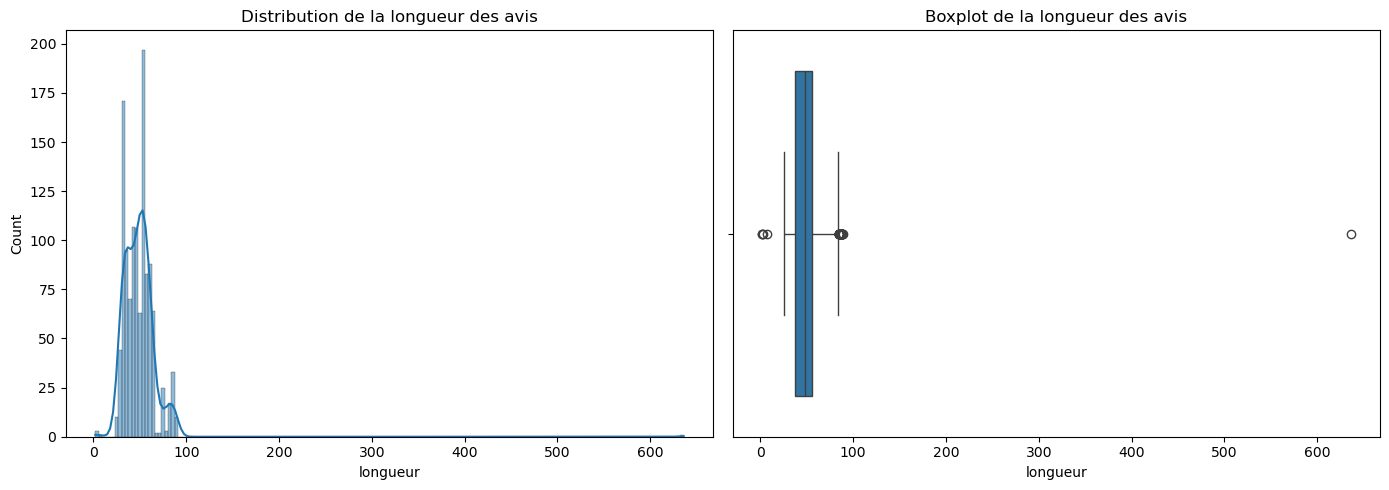

In [22]:
# Question 8 : Visualisation de la distribution de la longueur des avis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['longueur'], kde=True, ax=axes[0])
axes[0].set_title('Distribution de la longueur des avis')

sns.boxplot(x=df['longueur'], ax=axes[1])
axes[1].set_title('Boxplot de la longueur des avis')

plt.tight_layout()
plt.show()

**Question 8.a : Existe-t-il des textes anormalement longs ?**

Oui, très clairement. L'histogramme montre que la quasi-totalité des textes se concentre entre 0 et 100 caractères, mais le boxplot révèle un point isolé loin à droite, autour de 630-640 caractères — cohérent avec le max de 636 observé en Q7. C'est un texte extrême, complètement déconnecté du reste de la distribution.

**Question 8.b : Existe-t-il beaucoup de textes très courts ?**

Oui — le boxplot montre plusieurs points isolés à gauche, proches de 0-20 caractères, et l'histogramme confirme une petite barre non négligeable près de 0. Ce n'est pas un cas isolé unique comme le texte long (Q8.a), mais un petit groupe de textes anormalement courts (proches du minimum de 2 caractères vu en Q7) — potentiellement des avis peu informatifs ou tronqués.

In [23]:
# Question 9 : Détecter les textes vides
textes_vides = df[df['texte'].isna() | (df['texte'].str.strip() == '')]

print("Nombre de textes vides :", len(textes_vides))
textes_vides

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,NaN
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,NaN
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,NaN
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,NaN
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,NaN
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3.0


In [26]:
# Question 10 (re-corrigée) : exclure aussi les textes vides (pas seulement NaN)
df_texte_valide = df[df['texte'].notna() & (df['texte'].str.strip() != '')]
doublons_texte = df_texte_valide[df_texte_valide.duplicated(subset='texte', keep=False)].sort_values('texte')

print("Nombre de lignes impliquées dans un doublon de texte :", len(doublons_texte))
print("Nombre de textes uniques dupliqués :", doublons_texte['texte'].nunique())
doublons_texte[['id_avis', 'texte', 'source', 'produit']]

Nombre de lignes impliquées dans un doublon de texte : 1031
Nombre de textes uniques dupliqués : 154


,id_avis,texte,source,produit
312,AV0313,@client Excellent rapport qualité-prix.,mobile,Écouteurs AirSound
419,AV0420,@client Excellent rapport qualité-prix.,sav,Ordinateur NovaBook
1099,AV1100,@client Excellent rapport qualité-prix.,email,Tablette TabPlus
45,AV0046,@client Excellent rapport qualité-prix.,web,SmartPhone X
466,AV0467,@client Excellent rapport qualité-prix.,mobile,Ordinateur NovaBook
...,...,...,...,...
198,AV0199,Très satisfait de mon achat 👍 😊,web,Tablette TabPlus
5,AV0006,Très satisfait de mon achat 👍 😊,web,Ordinateur NovaBook
968,AV0969,Très satisfait de mon achat 👍 😊,email,SmartWatch Pro
745,AV0746,Très satisfait de mon achat 👍 😊,mobile,Écouteurs AirSound


**Question 10 : Doublons sur le texte **

Après exclusion des valeurs manquantes et des textes vides, 1031 avis sur 1194 textes valides (~86%) partagent leur texte avec au moins un autre avis, répartis sur 154 textes uniques dupliqués (moyenne ~6-7 répétitions par texte).

Note : il s'agit de doublons **sur le contenu textuel uniquement** (pas de lignes strictement identiques sur toutes les colonnes) — les avis concernés ont des `id_avis`, sources et produits différents. Ce taux élevé suggère un corpus généré à partir d'un nombre limité de phrases-types réutilisées, plutôt que des doublons au sens d'une erreur de collecte. Conformément à la consigne, ils seront traités comme doublons et supprimés en Partie 2 (un seul exemplaire conservé par texte identique).

In [27]:
# Question 11 : Équilibre des classes (sentiment)
df['sentiment'].value_counts()

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

In [28]:
print("\nProportions (%) :")
(df['sentiment'].value_counts(normalize=True) * 100).round(2)


Proportions (%) :


sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64

**Question 11 : Les classes sont-elles équilibrées ?**

Non, les classes sont clairement déséquilibrées :
- `positif` : 776 avis (64.67%)
- `neutre` : 246 avis (20.50%)
- `negatif` : 178 avis (14.83%)

Le ratio entre la classe la plus représentée et la moins représentée est d'environ 4.4:1, un déséquilibre modéré à significatif qui devra être pris en compte lors du découpage train/test (stratification) et du choix des métriques d'évaluation.

**Question 12 : Quelle est la classe majoritaire ?**

La classe majoritaire est `positif`, avec 776 avis, soit 64.67% du dataset.

**Question 13 : Métriques de classification à envisager**

L'accuracy seule serait trompeuse ici : un modèle qui prédirait systématiquement `positif` (la classe majoritaire) obtiendrait déjà ~64.67% d'accuracy sans avoir rien appris, alors qu'il échouerait totalement sur `neutre` et `negatif`.

Métriques plus adaptées à privilégier :
- **Precision, Recall et F1-score par classe**, pour évaluer la performance sur chaque sentiment individuellement (notamment `negatif`, la classe minoritaire, souvent la plus critique à détecter dans un contexte de satisfaction client)
- **F1-score macro** (moyenne non pondérée entre les 3 classes), qui ne favorise pas artificiellement la classe majoritaire
- **Matrice de confusion**, pour visualiser les confusions entre classes (ex: `neutre` mal classé en `positif`)

In [29]:
# Question 14 : Détecter les caractères particuliers 

In [31]:
# Question 14.a : Détection des emojis
emojis_pattern = r'👍|😀|😍|👎|😡|❤️|🙂|😞'
df['a_emoji'] = df['texte'].str.contains(emojis_pattern, na=False, regex=True)

print("Nombre de textes contenant un emoji :", df['a_emoji'].sum())

# Liste des emojis distincts effectivement rencontrés dans le corpus
import re
emojis_trouves = set()
for texte in df['texte'].dropna():
    emojis_trouves.update(re.findall(emojis_pattern, texte))
print("Emojis distincts trouvés :", emojis_trouves)

Nombre de textes contenant un emoji : 78
Emojis distincts trouvés : {'👍', '😡', '😍'}


In [32]:
# Question 14.b : Détection des URLs
df['a_url'] = df['texte'].str.contains(r'http', na=False, regex=True)

print("Nombre de textes contenant une URL :", df['a_url'].sum())

Nombre de textes contenant une URL : 143


In [33]:
# Question 14.c : Détection des hashtags
df['a_hashtag'] = df['texte'].str.contains(r'#\w+', na=False, regex=True)

print("Nombre de textes contenant un hashtag :", df['a_hashtag'].sum())

Nombre de textes contenant un hashtag : 127


In [34]:
# Question 14.d : Détection des mentions
df['a_mention'] = df['texte'].str.contains(r'@\w+', na=False, regex=True)

print("Nombre de textes contenant une mention :", df['a_mention'].sum())

Nombre de textes contenant une mention : 128


In [35]:
# Question 14.e : Détection des chiffres
df['a_chiffre'] = df['texte'].str.contains(r'\d', na=False, regex=True)

print("Nombre de textes contenant au moins un chiffre :", df['a_chiffre'].sum())

Nombre de textes contenant au moins un chiffre : 142


In [36]:
# Question 14.f : Détection des caractères spéciaux
# Caractères spéciaux = tout ce qui n'est ni lettre, ni chiffre, ni espace, ni ponctuation courante
caracteres_speciaux_pattern = r'[^\w\sàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ.,!?\'"-]'
df['a_caractere_special'] = df['texte'].str.contains(caracteres_speciaux_pattern, na=False, regex=True)

print("Nombre de textes contenant un caractère spécial :", df['a_caractere_special'].sum())

# Liste des caractères spéciaux distincts trouvés
caracteres_trouves = set()
for texte in df['texte'].dropna():
    caracteres_trouves.update(re.findall(caracteres_speciaux_pattern, texte))
print("Caractères spéciaux distincts trouvés :", caracteres_trouves)

Nombre de textes contenant un caractère spécial : 569
Caractères spéciaux distincts trouvés : {'👍', ':', '@', '/', '😊', '😍', '😡', '#'}


In [37]:
# Question 14.g : Détection de la ponctuation répétée
ponctuation_repetee_pattern = r'[!?.]{2,}'
df['a_ponctuation_repetee'] = df['texte'].str.contains(ponctuation_repetee_pattern, na=False, regex=True)

print("Nombre de textes avec ponctuation répétée :", df['a_ponctuation_repetee'].sum())

Nombre de textes avec ponctuation répétée : 141


In [38]:
# Question 15 : Nombre d'avis par source
df['source'].value_counts()

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64

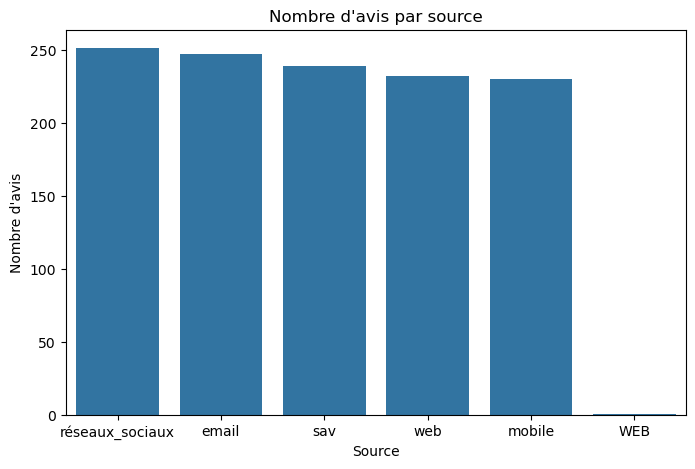

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='source', order=df['source'].value_counts().index)
plt.title("Nombre d'avis par source")
plt.xlabel('Source')
plt.ylabel("Nombre d'avis")
plt.show()

**Question 15 : Commentaire sur le nombre d'avis par source**

Les 5 sources principales sont relativement équilibrées entre elles : `réseaux_sociaux` (251), `email` (247), `sav` (239), `web` (232) et `mobile` (230) — aucune ne domine excessivement les autres.

Cependant, on remarque une anomalie de saisie : `WEB` (en majuscules) apparaît séparément avec seulement 1 avis, alors qu'il s'agit clairement de la même source que `web` (232 avis) — un simple problème de casse non uniformisée. Ce cas devra être corrigé lors du nettoyage (normalisation de la casse sur la colonne `source`), sans quoi cette source serait artificiellement sous-comptée par rapport à sa vraie fréquence (233 avis une fois fusionnée).

In [40]:
# Question 16 : Nombre d'avis par produit
df['produit'].value_counts()

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64

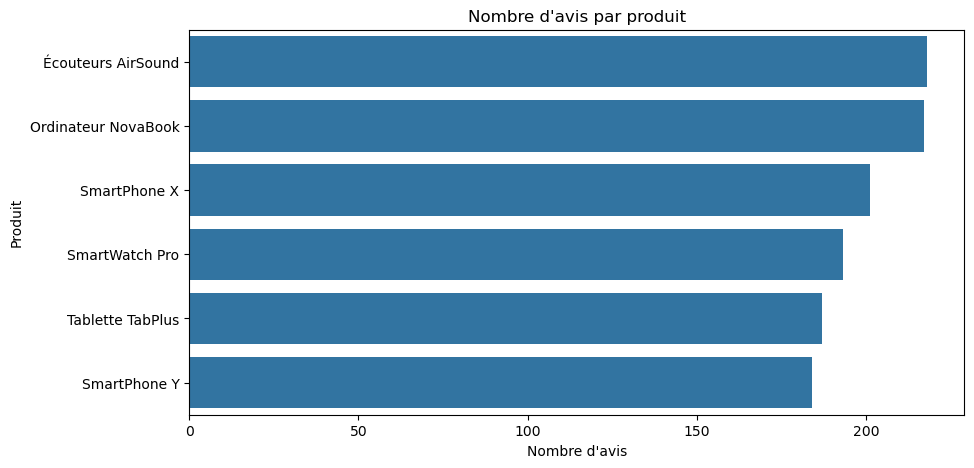

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='produit', order=df['produit'].value_counts().index)
plt.title("Nombre d'avis par produit")
plt.xlabel("Nombre d'avis")
plt.ylabel('Produit')
plt.show()

**Question 16 : Commentaire sur le nombre d'avis par produit**

Les 6 produits ont une répartition assez homogène, allant de 184 avis (`SmartPhone Y`) à 218 avis (`Écouteurs AirSound`) — un écart modéré, sans produit sur- ou sous-représenté de façon marquante. Contrairement à la colonne `source` (Q15), aucune anomalie de casse ou d'orthographe n'est visible ici, la variable semble propre.

# Partie 2 – Nettoyage

In [42]:
# Partie 2 - Question 1 : Suppression des lignes avec texte manquant ou vide
avant = df.shape[0]

df = df[df['texte'].notna() & (df['texte'].str.strip() != '')].copy()

apres = df.shape[0]
print("Lignes avant :", avant)
print("Lignes après :", apres)
print("Lignes supprimées :", avant - apres)

Lignes avant : 1200
Lignes après : 1194
Lignes supprimées : 6


In [43]:
# Partie 2 - Question 2 : Suppression des doublons sur le texte
avant = df.shape[0]

df = df.drop_duplicates(subset='texte', keep='first')

apres = df.shape[0]
print("Lignes avant :", avant)
print("Lignes après :", apres)
print("Lignes supprimées :", avant - apres)

Lignes avant : 1194
Lignes après : 317
Lignes supprimées : 877


In [44]:
# Partie 2 - Question 3 : Suppression des URLs
df['texte_sans_url'] = df['texte'].str.replace(r'http\S+', '', regex=True)

df[['texte', 'texte_sans_url']].head(10)

,texte,texte_sans_url
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 #avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la d...
9,@client Livraison rapide et produit conforme à...,@client Livraison rapide et produit conforme à...


In [45]:
# Vérification ciblée sur les textes qui contenaient une URL
df[df['a_url'] == True][['texte', 'texte_sans_url']].head(5)

,texte,texte_sans_url
16,"Produit parfait, rien à signaler. https://exam...","Produit parfait, rien à signaler."
30,"Très bonne expérience, simple et efficace. htt...","Très bonne expérience, simple et efficace."
31,"Je viens de recevoir le produit, à voir dans l...","Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam...","Produit parfait, rien à signaler."
35,"Très bon produit, la qualité est au rendez-vou...","Très bon produit, la qualité est au rendez-vous."


**Question 4 : Stratégie de traitement des mentions et hashtags**

- **Mentions** (`@nom`) : suppression complète. Elles identifient un destinataire (client, service) sans porter d'information de sentiment.
- **Hashtags** (`#mot`) : suppression du symbole `#` uniquement, en conservant le mot qui suit. Un hashtag comme "#top" ou "#déçu" peut contenir un indice de sentiment fort — le supprimer entièrement ferait perdre cette information utile pour la classification.

In [46]:
# Partie 2 - Question 4 (mentions) : Suppression complète des mentions
df['texte_sans_url'] = df['texte_sans_url'].str.replace(r'@\w+', '', regex=True)

df[df['a_mention']][['texte', 'texte_sans_url']].head(5)

,texte,texte_sans_url
9,@client Livraison rapide et produit conforme à...,Livraison rapide et produit conforme à mes at...
32,@client Service client réactif et commande reç...,Service client réactif et commande reçue rapi...
40,@client La qualité est correcte sans être exce...,La qualité est correcte sans être exceptionne...
44,"@client Je recommande vivement, tout fonctionn...","Je recommande vivement, tout fonctionne parfa..."
45,@client Excellent rapport qualité-prix.,Excellent rapport qualité-prix.


In [47]:
# Partie 2 - Question 4 (hashtags) : Suppression du # uniquement, conservation du mot
df['texte_sans_url'] = df['texte_sans_url'].str.replace(r'#(\w+)', r'\1', regex=True)

df[df['a_hashtag']][['texte', 'texte_sans_url']].head(5)

,texte,texte_sans_url
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
12,La batterie tient vraiment bien et l'écran est...,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis,Produit correct pour son prix. avis
38,"Très bonne expérience, simple et efficace. #avis","Très bonne expérience, simple et efficace. avis"
76,Excellent rapport qualité-prix. #avis,Excellent rapport qualité-prix. avis


In [48]:
# Partie 2 - Question 5 : Nettoyage des espaces
df['texte_sans_url'] = df['texte_sans_url'].str.replace(r'\s+', ' ', regex=True).str.strip()

df[['texte', 'texte_sans_url']].head(10)

,texte,texte_sans_url
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la descrip...
9,@client Livraison rapide et produit conforme à...,Livraison rapide et produit conforme à mes att...


**Question 6 : Stratégie de traitement de la ponctuation**

Pour la classification de sentiment, la ponctuation répétée (`!!!`, `???`, `...`) porte souvent une charge émotionnelle (intensité, insistance) — un signal utile à ne pas perdre. On choisit donc de :
- **Normaliser** la ponctuation répétée en un seul caractère (`!!!` → `!`), pour éviter que le vocabulaire n'explose inutilement (Bag of Words/TF-IDF traiteraient "!!!", "!!" et "!" comme des tokens distincts), tout en conservant le signal qu'un point d'exclamation ou d'interrogation était présent.
- **Supprimer** la ponctuation "neutre" non répétée (virgules, points simples, guillemets) qui n'apporte pas d'information de sentiment, tout en gardant `!` et `?` (même normalisés à 1 occurrence), qui eux sont porteurs de sens émotionnel.

In [49]:
# Partie 2 - Question 6 : Traitement de la ponctuation
# Normaliser la ponctuation répétée (!!!, ???, ... -> un seul caractère)
df['texte_sans_url'] = df['texte_sans_url'].str.replace(r'([!?.]){2,}', r'\1', regex=True)

# Supprimer toute ponctuation SAUF ! et ?
df['texte_sans_url'] = df['texte_sans_url'].str.replace(r'[^\w\s!?àâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ]', '', regex=True)

df[df['a_ponctuation_repetee']][['texte', 'texte_sans_url']].head(5)

,texte,texte_sans_url
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait !
10,Très satisfait de mon achat 👍 !!!,Très satisfait de mon achat !
14,Qualité décevante pour ce prix. !!!,Qualité décevante pour ce prix !
25,"Produit reçu endommagé, je suis mécontent. !!!",Produit reçu endommagé je suis mécontent !
59,Le produit ne fonctionne déjà plus. !!!,Le produit ne fonctionne déjà plus !


In [52]:
# Partie 2 - Question 7 : Fonction de nettoyage globale (Q1 à Q6)
def nettoyer_texte(texte):
    """
    Nettoie un texte individuel : suppression des URLs, mentions, hashtags
    (symbole retiré), apostrophes remplacées par un espace, normalisation
    ponctuation répétée, suppression ponctuation neutre, nettoyage des espaces.
    """
    texte = re.sub(r'http\S+', '', texte)
    texte = re.sub(r'@\w+', '', texte)
    texte = re.sub(r'#(\w+)', r'\1', texte)
    texte = re.sub(r"['’]", ' ', texte)
    texte = re.sub(r'([!?.]){2,}', r'\1', texte)
    texte = re.sub(r'[^\w\s!?àâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ]', '', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte


def nettoyer_dataset(df_source):
    """
    Applique l'ensemble du nettoyage de la Partie 2 sur un DataFrame :
    Q1 (suppression valeurs manquantes/vides), Q2 (suppression doublons de texte),
    puis Q3-Q6 (nettoyage du contenu texte) via nettoyer_texte().
    Retourne un nouveau DataFrame avec la colonne 'texte_clean' ajoutée.
    """
    df_resultat = df_source.copy()
    df_resultat = df_resultat[df_resultat['texte'].notna() & (df_resultat['texte'].str.strip() != '')]
    df_resultat = df_resultat.drop_duplicates(subset='texte', keep='first')
    df_resultat['texte_clean'] = df_resultat['texte'].apply(nettoyer_texte)
    return df_resultat

In [53]:
# Partie 2 - Question 8 : Application de la fonction de nettoyage globale
df = nettoyer_dataset(df)

print("Nombre de lignes après nettoyage global :", df.shape[0])
df[['texte', 'texte_clean']].head(10)

Nombre de lignes après nettoyage global : 317


,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait !
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la descrip...
9,@client Livraison rapide et produit conforme à...,Livraison rapide et produit conforme à mes att...


In [54]:
# Partie 2 - Question 9 : Vérification texte vs texte_clean (10 premières observations)
for i in range(10):
    print(f"--- Ligne {i} ---")
    print("texte       :", df['texte'].iloc[i])
    print("texte_clean :", df['texte_clean'].iloc[i])
    print()

--- Ligne 0 ---
texte       : Très  bonne  expérience,  simple  et  efficace.
texte_clean : Très bonne expérience simple et efficace

--- Ligne 1 ---
texte       : Très satisfait de mon achat 👍 #avis
texte_clean : Très satisfait de mon achat avis

--- Ligne 2 ---
texte       : Produit  parfait,  rien  à  signaler.
texte_clean : Produit parfait rien à signaler

--- Ligne 3 ---
texte       : Produit excellent, je suis très satisfait. !!!
texte_clean : Produit excellent je suis très satisfait !

--- Ligne 4 ---
texte       : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
texte_clean : LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST SUPERBE

--- Ligne 5 ---
texte       : Très satisfait de mon achat 👍 😊
texte_clean : Très satisfait de mon achat

--- Ligne 6 ---
texte       : SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.
texte_clean : SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT

--- Ligne 7 ---
texte       : Très  satisfait  de  mon  achat  👍
texte_clean : Très satisfa